In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
DATA_DIR = Path.home() / "project/crc-pm/result/dr-anno" / "ready_for_anno.h5ad"
adata = sc.read_h5ad(str(DATA_DIR))

In [3]:
# use different res
leiden_res = [0.25, 0.5, 0.75, 1.0, 2.0]
for i in leiden_res:
    sc.tl.leiden(adata, key_added=f"leiden_res{i}", resolution=i, flavor="igraph", n_iterations=2)

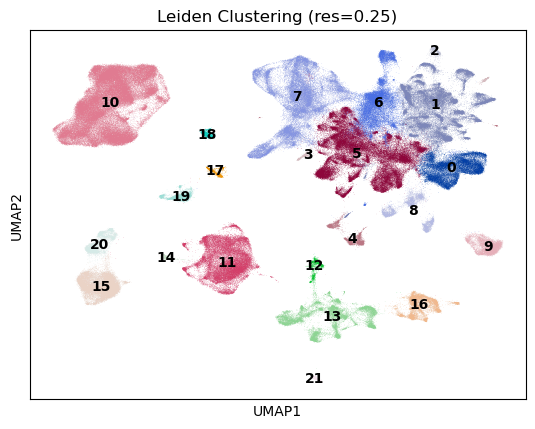

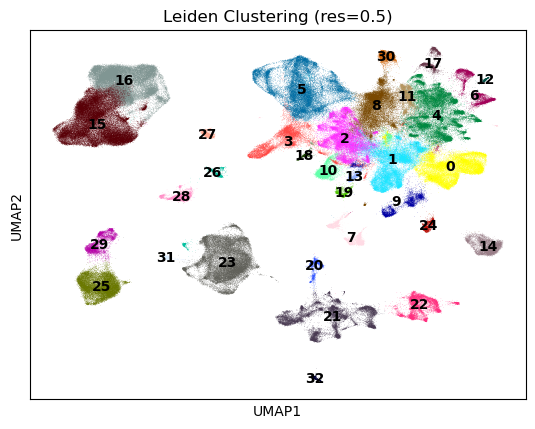

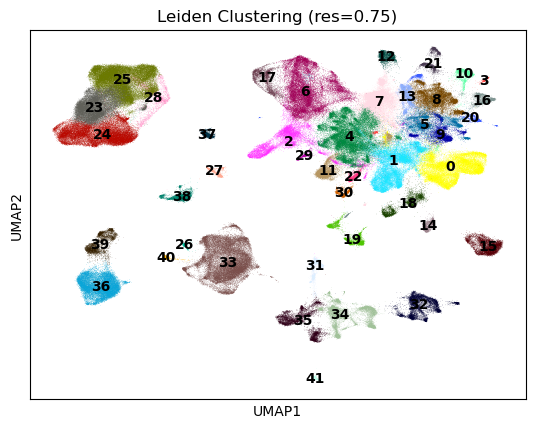

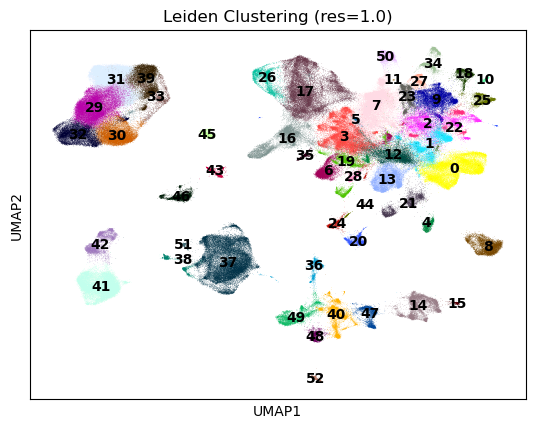

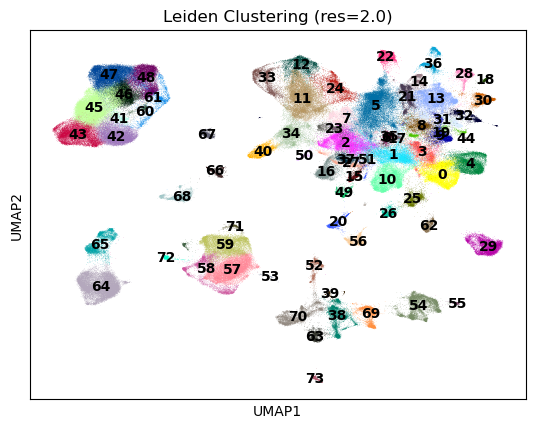

In [4]:
for i in leiden_res:
    sc.pl.umap(
        adata,
        color=f"leiden_res{i}",
        legend_loc="on data",
        title=f"Leiden Clustering (res={i})",
    )

In [5]:
adata.obs = adata.obs.rename(columns={"CellType": "scANVI_label"})

In [10]:
coarse_label_dict = {
    'Unknown' : 'Unknown',
    'Cancer TA-like' : 'Tumour',
    'Cancer Colonocyte-like' : 'Tumour',
    'Cancer Goblet-like' : 'Tumour',
    'Cancer Crypt-like' : 'Tumour',
    'Cancer BEST4' : 'Tumour',
    'Macrophage': 'Myeloid' ,
    'Monocyte classical': 'Mono' ,
    'Tuft': 'Epithelium',
    'TA progenitor': 'Epithelium',
    'Enteroendocrine': 'Epithelium',
    'Colonocyte': 'Epithelium',
    'Mast cell': 'Mast',
    'Endothelial venous': 'Endothelium', 
    'Endothelial arterial': 'Endothelium', 
    'Monocyte non-classical': 'Mono' , 
    'Plasma IgA': 'Plasma', 
    'Goblet': 'Epithelium', 
    'cDC2': 'DC', 
    'T cell CD8': 'T/NK/ILC', 
    'T cell regulatory': 'T/NK/ILC', 
    'B cell memory': 'B', 
    'cDC1': 'DC', 
    'DC3': 'DC', 
    'Fibroblast S3': 'Stromal',
    'DC mature': 'DC', 
    'Pericyte': 'Stromal', 
    'Fibroblast S1': 'Stromal', 
    'Fibroblast S2': 'Stromal', 
    'GC B cell': 'GC B', 
    'T cell CD4': 'T/NK/ILC', 
    'Plasma IgG': 'Plasma', 
    'B cell naive': 'B', 
    'ILC':'T/NK/ILC', 
    'pDC': 'DC', 
    'Plasma IgM': 'Plasma', 
    'Cancer cell circulating': 'Tumour', 
    'NK cell': 'NK', 
    'Schwann cell': 'Stromal', 
    'Eosinophil': 'Myeloid', 
    'Endothelial lymphatic':'Endothelium', 
    'Neutrophil': 'Myeloid', 
    'T cell gd': 'T/NK/ILC', 
    'Plasmablast': 'Plasma', 
    'Colonocyte BEST4': 'Epithelium', 
    'Crypt cell': 'Epithelium', 
    'T cell CD4 naive': 'T/NK/ILC', 
    'T cell CD8 naive': 'T/NK/ILC',
}
coarse = [coarse_label_dict[_] for _ in adata.obs['scANVI_label']]
adata.obs['scANVI_label_coarse'] = coarse


/home/zhekai/miniconda3/envs/pm/lib/python3.13/site-packages/anndata/_core/anndata.py:1255: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


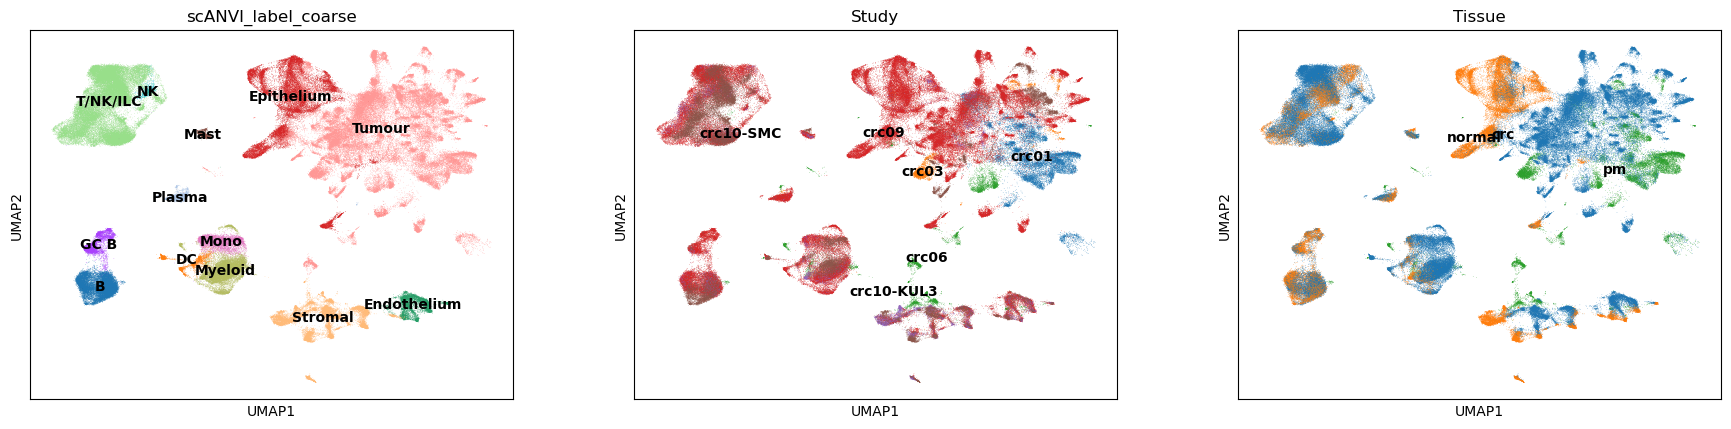

In [11]:
sc.pl.umap(adata[adata.obs['scANVI_label_coarse'] != 'Unknown' ],
    color= ["scANVI_label_coarse",'Study','Tissue'],
    legend_loc="on data",
)

/home/zhekai/miniconda3/envs/pm/lib/python3.13/site-packages/scanpy/plotting/_utils.py:509: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


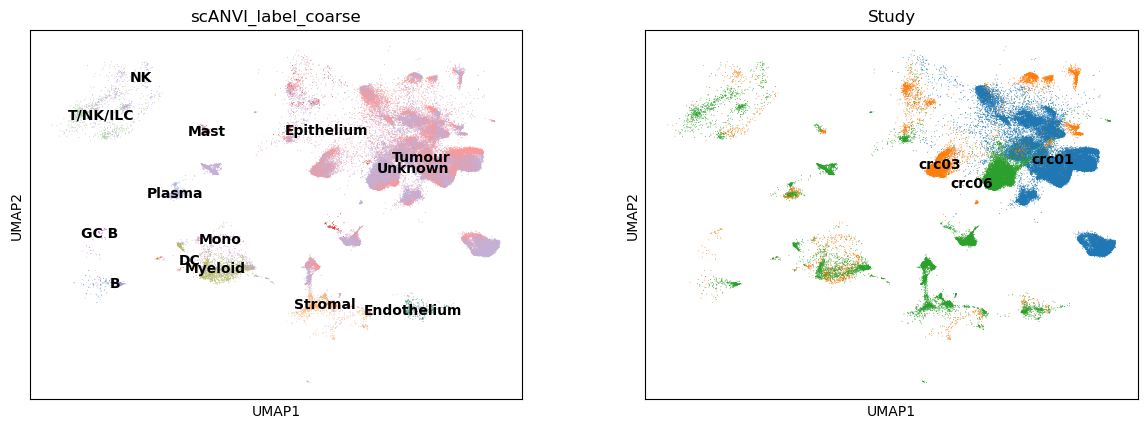

In [32]:
sc.pl.umap(adata[adata.obs['Study'].isin(['crc01', 'crc03', 'crc06'])],
    color= ["scANVI_label_coarse",'Study'],
    legend_loc="on data",)

In [ ]:
### construct cluster-anno relation
annodict_res025 = {
    0: 'Tumor',
    1: 'Tumor',
    2: 'Tumor',
    3: 'Tumor',
    4: 'Epithelium',
    5: 'Tumor',
    6: 'Tumor',
    7: 'Epithelium',
    8: 'Tumor',
    9: 'Tumor',
    10: 'T/NK/ILC',
    11: 'Myeloid',
    12: 'Tumor',
    13: 'Stromal',
    14: 'Myeloid',
    15: 'B',
    16: 'Endothelium',
    17: 'Tumor',
    18: 'Mast',
    19: 'Plasma',
    20: 'GC B',
    21: 'Stromal',
}

In [21]:
adata.obs['man_anno_coarse'] = [annodict_res025[int(_)] for _ in adata.obs['leiden_res0.25']]

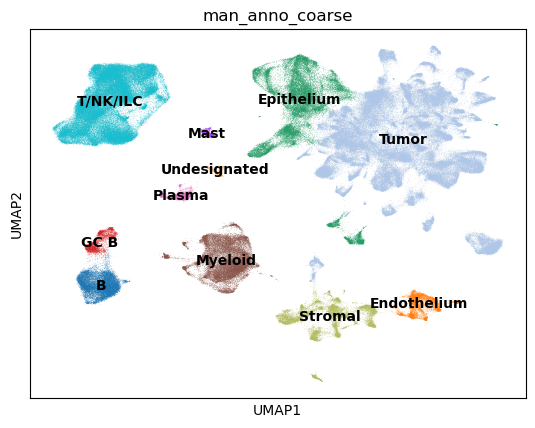

In [24]:
sc.pl.umap(adata,
    color= ['man_anno_coarse'],
    legend_loc="on data",
)

In [43]:
sc.tl.rank_genes_groups(
    adata,
    layer="log1p",
    groupby="leiden_res0.25",
    method="wilcoxon",
    key_added="dea_leiden_res0.25",
)

sc.tl.dendrogram(
    adata,
    groupby="leiden_res0.25",
    use_rep="X_scVI",
)

/home/zhekai/miniconda3/envs/pm/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/home/zhekai/miniconda3/envs/pm/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/home/zhekai/miniconda3/envs/pm/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:463: PerformanceWarni

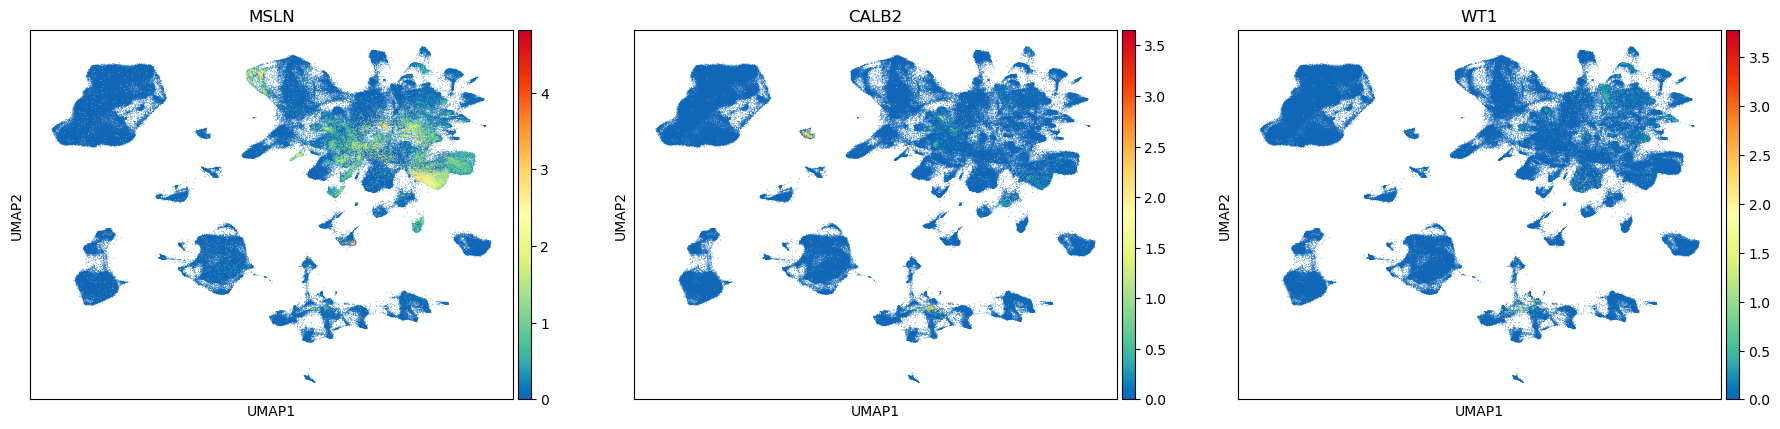

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, rgb_to_hsv, hsv_to_rgb

# Spectral_r: 去掉两端偏暗部分 + 提高饱和度
base = plt.get_cmap("Spectral_r")

colors = base(np.linspace(0.08, 0.92, 256))
hsv = rgb_to_hsv(colors[:, :3])

hsv[:, 1] = np.clip(hsv[:, 1] * 1.35, 0, 1)  # saturation ↑
colors[:, :3] = hsv_to_rgb(hsv)

spectral_r_sat = ListedColormap(colors)

sc.pl.umap(
    adata,
    # color=["EPCAM", "FABP1", "PLA2G2A",],
    # color=["LGR5", "EMP1", "LAMC2","PTGS2",],
    color = ['MSLN','CALB2', 'WT1',],
    gene_symbols="gene_name",
    layer="log1p",
    cmap=spectral_r_sat,
    ncols=3,
    size=1,
)